In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
# START -> RETRIEVE -> GENERATE -> END

from typing_extensions import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: list
    answer: str

graph_builder = StateGraph(AgentState)

In [3]:
from langchain_tavily import TavilySearch

tavily_search_tool = TavilySearch(
    max_results=3,
    topic="general",
)

def web_search(state: AgentState):
    query = state['query']
    response = tavily_search_tool.invoke(query)
    return {'context': response}

In [4]:
from langchain import hub
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

generate_prompt = hub.pull('rlm/rag-prompt')
generate_llm = ChatOpenAI(model='gpt-4o', max_tokens=100)
def web_generate(state: AgentState) -> AgentState:
    context = state['context']
    query = state['query']
    rag_chain = generate_prompt | generate_llm | StrOutputParser()
    response = rag_chain.invoke({'question': query, 'context': context})
    return {'answer': response}

/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

basic_llm = ChatOpenAI(model='gpt-4o-mini')

def basic_generate(state: AgentState):
    query = state['query']
    basic_llm_chain = basic_llm | StrOutputParser()
    response = basic_llm_chain.invoke(query)
    return {'answer': response}



In [6]:
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from typing import Literal

class Route(BaseModel):
    target: Literal['vector_store', 'llm', 'web_search'] = Field(
        description="The target for the query to answer"
        )

router_system_prompt = """
You are an expert at routing a user's question to 'vector_store', 'llm', or 'web_search'.
'vector_store' contains information about income tax up to December 2024.
if you think the question is simple enough use 'llm'
if you think you need to search the web to answer the question use 'web_search'
"""
router_prompt = ChatPromptTemplate.from_messages([
    ('system', router_system_prompt),
    ('user', '{query}'),
])

router_llm = ChatOpenAI(model='gpt-4o-mini')
structured_router_llm = router_llm.with_structured_output(Route)
def router(state: AgentState):
    query = state['query']
    router_chain = router_prompt | structured_router_llm | StrOutputParser()
    response = router_chain.invoke({'query': query})
    print(response)
    return response


In [7]:
from income_tax_graph import graph as income_tax_subgraph
graph_builder.add_node('income_tax_agent', income_tax_subgraph)
graph_builder.add_node('web_search', web_search)
graph_builder.add_node('web_generate', web_generate)
graph_builder.add_node('basic_generate', basic_generate)


/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
/Users/jys/code/study/study-llm-agent/venv/lib/python3.11/site-packages/langsmith/client.py:278: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [8]:
from langgraph.graph import START, END

graph_builder.add_conditional_edges(
    START,
    router,
    {
        'vector_store': 'income_tax_agent',
        'llm': 'basic_generate',
        'web_search': 'web_search',
    }
)
graph_builder.add_edge('web_search', 'web_generate')
graph_builder.add_edge('basic_generate', END)
graph_builder.add_edge('income_tax_agent', END)
graph_builder.add_edge('web_generate', END)

In [9]:
graph = graph_builder.compile()

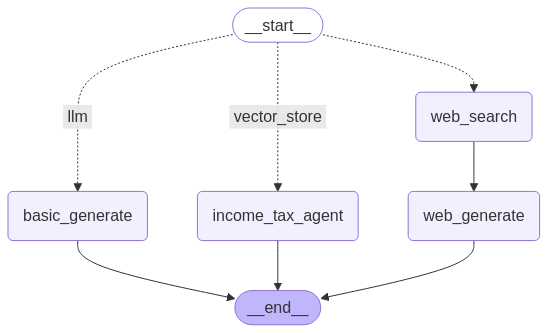

In [10]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))



In [11]:
initial_state = {'query': '연봉 5천만원의 거주자의 세금'}
graph.invoke(initial_state)

이 질문은 소득세에 대한 정보가 필요합니다. 따라서 'vector_store'로 라우팅하겠습니다.


KeyError: "이 질문은 소득세에 대한 정보가 필요합니다. 따라서 'vector_store'로 라우팅하겠습니다."